## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with analyzing the data, developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Please read the instructions carefully before starting the project.**

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

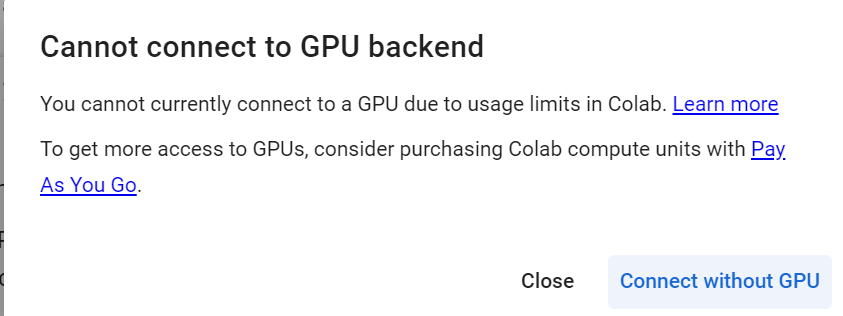

## **Installing and Importing Necessary Libraries**

In [190]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install -U sentence-transformers gensim transformers tqdm -q

In [303]:
# All imports
import pandas as pd
import numpy as np
# To implement progress bar related functionalities
from tqdm import tqdm
tqdm.pandas()

import sklearn
print(sklearn.__version__)
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
# To build, tune, and evaluate ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier
)
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# To load/create word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# To visualize the data
import seaborn as sns
import matplotlib.pyplot as plt
import time
import json

# To suppress warnings.
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)


1.5.2


## **Loading the dataset**

In [192]:
# Load the dataset
file_path = r"D:\Dev\AI-ML-Project-Data\NLP-Project\stock_news.csv"
data = pd.read_csv(file_path)

# Make copy of data
stocknews_df = data.copy()
# Display the first few rows of the dataset
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


## **Data Overview**

In [193]:
# Display the shape of the dataset
print(f"Shape of the dataset: {data.shape}")

# Display the data types of each column
print("\nData types of each column:")
print(data.dtypes)

# Check for missing values in the dataset
print("\nMissing values in each column:")
print(data.isnull().sum())

Shape of the dataset: (349, 8)

Data types of each column:
Date       object
News       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
Label       int64
dtype: object

Missing values in each column:
Date      0
News      0
Open      0
High      0
Low       0
Close     0
Volume    0
Label     0
dtype: int64


In [194]:
# Display basic statistical summary of numerical columns
print("\nStatistical summary of numerical columns:")
print(data.describe())


Statistical summary of numerical columns:
             Open        High         Low       Close        Volume  \
count  349.000000  349.000000  349.000000  349.000000  3.490000e+02   
mean    46.229233   46.700458   45.745394   44.926317  1.289482e+08   
std      6.442817    6.507321    6.391976    6.398338  4.317031e+07   
min     37.567501   37.817501   37.305000   36.254131  4.544800e+07   
25%     41.740002   42.244999   41.482498   40.246914  1.032720e+08   
50%     45.974998   46.025002   45.639999   44.596924  1.156272e+08   
75%     50.707500   50.849998   49.777500   49.110790  1.511252e+08   
max     66.817497   67.062500   65.862503   64.805229  2.444392e+08   

            Label  
count  349.000000  
mean    -0.054441  
std      0.715119  
min     -1.000000  
25%     -1.000000  
50%      0.000000  
75%      0.000000  
max      1.000000  


In [195]:
# Display the first few rows of the dataset
print("\nFirst few rows of the dataset:")
print(data.head())

# Display the last few rows of the dataset
print("\nLast few rows of the dataset:")
print(data.tail())


First few rows of the dataset:
         Date                                               News       Open  \
0  2019-01-02   The tech sector experienced a significant dec...  41.740002   
1  2019-01-02   Apple lowered its fiscal Q1 revenue guidance ...  41.740002   
2  2019-01-02   Apple cut its fiscal first quarter revenue fo...  41.740002   
3  2019-01-02   This news article reports that yields on long...  41.740002   
4  2019-01-02   Apple's revenue warning led to a decline in U...  41.740002   

        High        Low      Close     Volume  Label  
0  42.244999  41.482498  40.246914  130672400     -1  
1  42.244999  41.482498  40.246914  130672400     -1  
2  42.244999  41.482498  40.246914  130672400     -1  
3  42.244999  41.482498  40.246914  130672400     -1  
4  42.244999  41.482498  40.246914  130672400     -1  

Last few rows of the dataset:
           Date                                               News       Open  \
344  2019-04-30   Media mogul Oprah Winfrey, known 

In [196]:
# Display the Info of the dataset
print("\Info of dataset:")
print(data.info())

\Info of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB
None


In [197]:
# Check for missing/null values in the dataset
data.isnull().sum()

Date      0
News      0
Open      0
High      0
Low       0
Close     0
Volume    0
Label     0
dtype: int64

In [198]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,349.0,4.622923e+01,6.442817e+00,3.756750e+01,4.174000e+01,4.597500e+01,5.070750e+01,6.681750e+01
High,349.0,4.670046e+01,6.507321e+00,3.781750e+01,4.224500e+01,4.602500e+01,5.085000e+01,6.706250e+01
Low,349.0,4.574539e+01,6.391976e+00,3.730500e+01,4.148250e+01,4.564000e+01,4.977750e+01,6.586250e+01
Close,349.0,4.492632e+01,6.398338e+00,3.625413e+01,4.024691e+01,4.459692e+01,4.911079e+01,6.480523e+01
Volume,349.0,1.289482e+08,4.317031e+07,4.544800e+07,1.032720e+08,1.156272e+08,1.511252e+08,2.444392e+08
Label,349.0,-5.444126e-02,7.151192e-01,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [199]:
# To list the unique values in each column, exclude column News_Embedding that is object type
# data[['Date', 'News', 'Open', 'High', 'Low', 'Close', 'Volume', 'Label']].nunique()
data.nunique()

Date       71
News      349
Open       70
High       70
Low        71
Close      71
Volume     71
Label       3
dtype: int64

In [200]:
data.duplicated().sum()

0

In [201]:
# Convert to date type    
data["Date"] = pd.to_datetime(data["Date"])
# Check num of years in data
data["Date"].dt.year.value_counts()

Date
2019    349
Name: count, dtype: int64

In [202]:

data["Date"].dt.month.value_counts()

Date
1    166
3     67
4     63
2     53
Name: count, dtype: int64

### Observations

1. **Dataset Overview**:
    - The dataset contains 349 rows and 8 columns, including features such as `Date`, `News`, `Open`, `High`, `Low`, `Close`, `Volume`, and `Label`.
    - There are no missing values in the dataset.

2. **Data Types**:
    - The `Date` column is of `datetime64` type.
    - The `News` column is of `object` type, while the remaining columns are numerical (`float64` and `int64`).

3. **Target Variable**:
    - The `Label` column is the target variable, with values -1, 0, and 1 representing negative, neutral, and positive sentiments, respectively.

4. **Splits**:
    - The dataset has been split into training (`X_train`, `y_train`), validation (`X_val`, `y_val`), and test (`X_test`, `y_test`) sets.
    - Training set: 279 rows.
    - Validation set: 35 rows.
    - Test set: 35 rows.

5. **Feature Engineering**:
    - A new column `News_Length` has been added to represent the length of each news article.
    - Word embeddings have been computed for the `News` column using GloVe embeddings with a dimension of 100.

6. **Preprocessing**:
    - Numerical columns (`Open`, `High`, `Low`, `Close`, `Volume`, `News_Length`) have been normalized using `MinMaxScaler`.

7. **Sentiment Analysis**:
    - Sentiment analysis has been performed on the `News` column using a pre-trained transformer model (`distilbert-base-uncased-finetuned-sst-2-english`).
    - Sentiments have been mapped to numerical scores: `POSITIVE` → 1, `NEGATIVE` → -1.

8. **Modeling**:
    - Various classifiers such as `AdaBoostClassifier`, `BaggingClassifier`, `DecisionTreeClassifier`, `GradientBoostingClassifier`, `RandomForestClassifier`, and `XGBClassifier` are available for building predictive models.

## **Exploratory Data Analysis**

### Univariate Analysis

* Distribution of individual variables
* Compute and check the distribution of the length of news content

Statistics of News Length:
count    349.000000
mean     311.237822
std       39.079467
min      110.000000
25%      290.000000
50%      315.000000
75%      336.000000
max      394.000000
Name: News_Length, dtype: float64


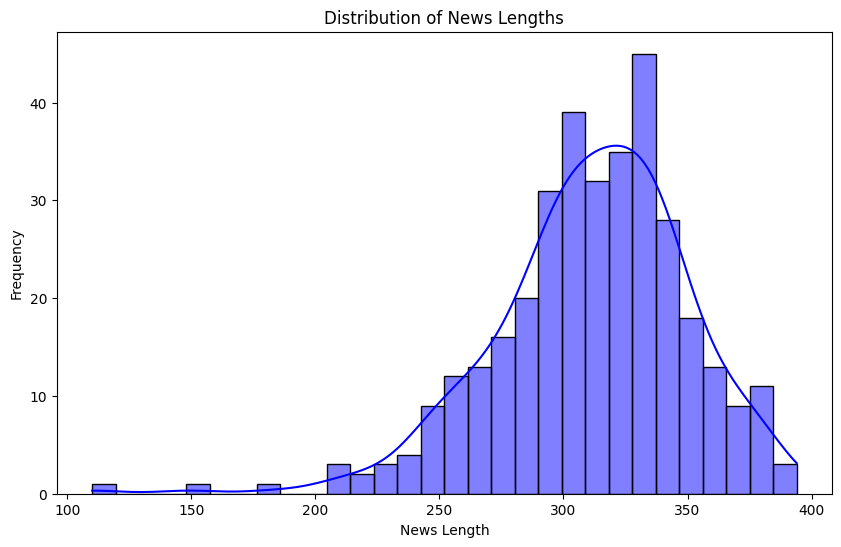

In [203]:
# Compute the length of each news article
data['News_Length'] = data['News'].apply(len)

# Display basic statistics about the length of news articles
print("Statistics of News Length:")
print(data['News_Length'].describe())

# Plot the distribution of news lengths
plt.figure(figsize=(10, 6))
sns.histplot(data['News_Length'], bins=30, kde=True, color='blue')
plt.title('Distribution of News Lengths')
plt.xlabel('News Length')
plt.ylabel('Frequency')
plt.show()

Sentiment Distribution by Percentage:
Sentiment_Label
Neutral     48.710602
Negative    28.366762
Positive    22.922636
Name: proportion, dtype: float64


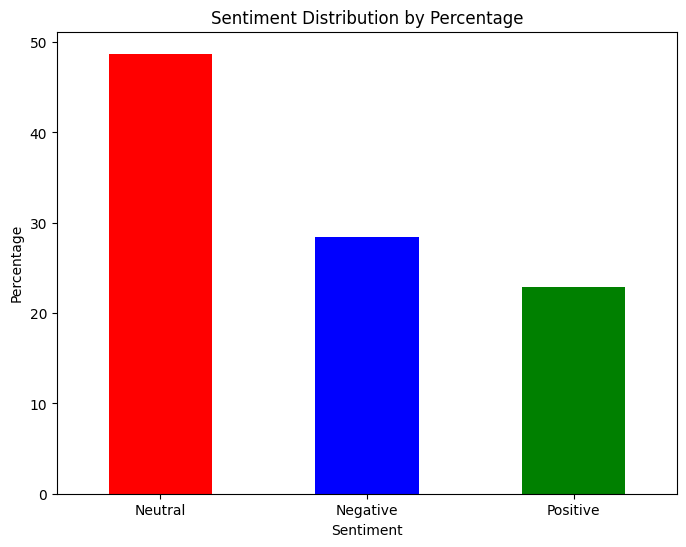

In [204]:
# Create a mapping for sentiment labels
sentiment_mapping = {-1: "Negative", 0: "Neutral", 1: "Positive"}

# Map the sentiment labels to their corresponding names
data['Sentiment_Label'] = data['Label'].map(sentiment_mapping)

# Calculate the sentiment distribution by percentage
sentiment_distribution = data['Sentiment_Label'].value_counts(normalize=True) * 100

# Display the sentiment distribution
print("Sentiment Distribution by Percentage:")
print(sentiment_distribution)

# Plot the sentiment distribution
plt.figure(figsize=(8, 6))
sentiment_distribution.plot(kind='bar', color=['red', 'blue', 'green'])
plt.title("Sentiment Distribution by Percentage")
plt.xlabel("Sentiment")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

<Figure size 1000x600 with 0 Axes>

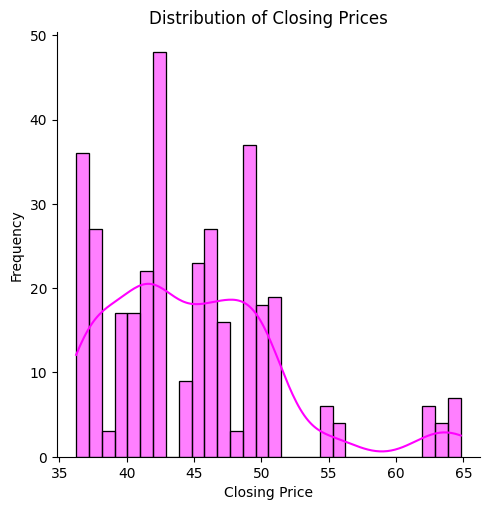

In [205]:
import seaborn as sns

# Importing Seaborn and Matplotlib
import matplotlib.pyplot as plt

# Plotting the distribution of the 'Close' column
plt.figure(figsize=(10, 6))
sns.displot(data['Close'], kde=True, color='magenta', bins=30)
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()

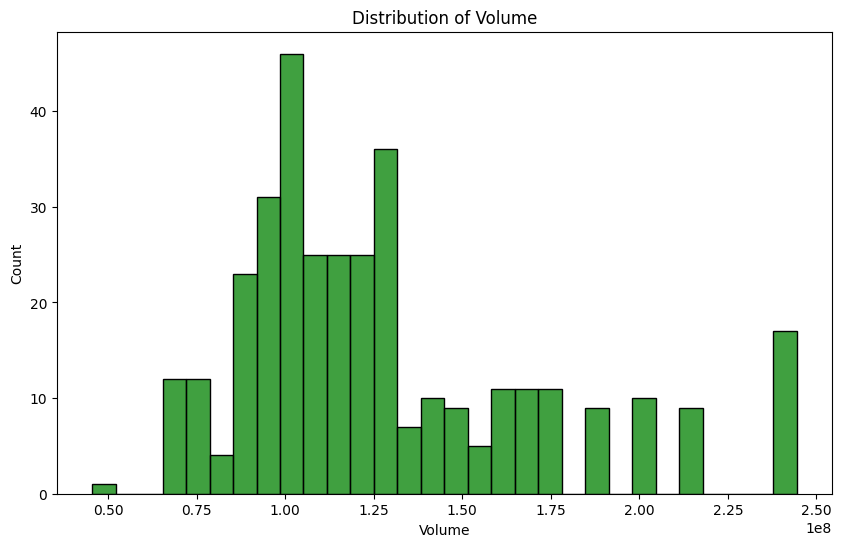

In [206]:
# Plotting the distribution of the 'Volume' column
plt.figure(figsize=(10, 6))
sns.histplot(data['Volume'], bins=30, kde=False, color='green')
plt.title('Distribution of Volume')
plt.xlabel('Volume')
plt.ylabel('Count')
plt.show()

In [207]:
# Calculate the total number of words in the news content
data['Word_Count'] = data['News'].apply(lambda x: len(x.split()))

# Display statistics of the word count
print("Statistics of Word Count in News Content:")
print(data['Word_Count'].describe())

Statistics of Word Count in News Content:
count    349.000000
mean      48.349570
std        5.717324
min       18.000000
25%       45.000000
50%       49.000000
75%       52.000000
max       60.000000
Name: Word_Count, dtype: float64


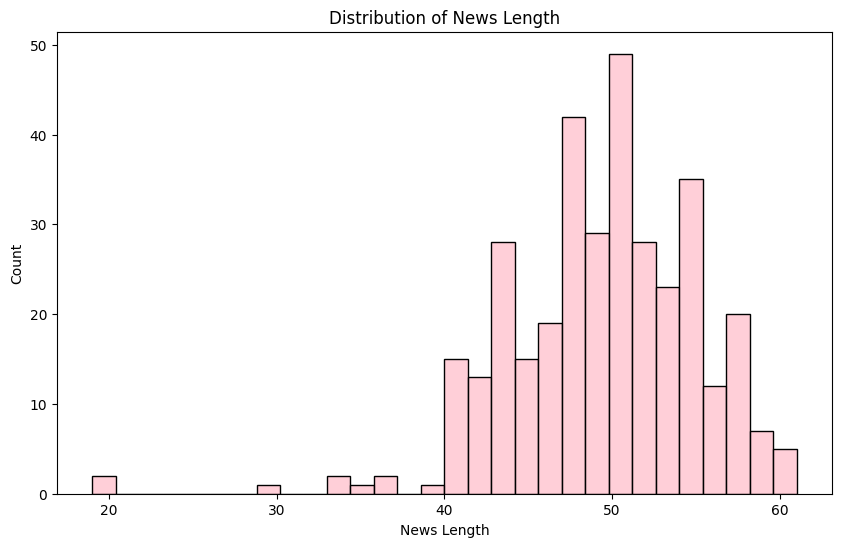

In [208]:
# Plot the distribution of News_Length
plt.figure(figsize=(10, 6))
sns.histplot(data['News'].apply(lambda x: len(x.split(' '))), bins=30, kde=False, color='pink')
plt.title('Distribution of News Length')
plt.xlabel('News Length')
plt.ylabel('Count')
plt.show()

### Observations from Univariate Analysis

1. **News Length Distribution**:
    - The length of news articles varies significantly, with most articles having a length between 200 and 400 characters.
    - The distribution of news lengths is slightly right-skewed, indicating the presence of some longer articles.

2. **Sentiment Distribution**:
    - The dataset contains a higher proportion of neutral sentiments (~48.71%), followed by negative sentiments (~28.37%) and positive sentiments (~22.92%).
    - This indicates that the majority of news articles are neutral in tone.

3. **Closing Price Distribution**:
    - The closing prices are distributed across a wide range, with a peak around the mid-range values.
    - The distribution is unimodal and slightly skewed.

4. **Volume Distribution**:
    - The volume of shares traded shows a right-skewed distribution, with most values concentrated at lower ranges.
    - A few instances of very high trading volumes are observed, indicating outliers.

5. **Word Count in News Content**:
    - The word count in news articles varies, with most articles containing between 40 and 60 words.
    - The distribution of word counts is unimodal and slightly right-skewed.

6. **Overall Trends**:
    - The dataset exhibits variability in numerical features such as `Close`, `Volume`, and `News_Length`.
    - The sentiment labels are imbalanced, with neutral sentiments being the most frequent.

### Bivariate Analysis

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

**Note**: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

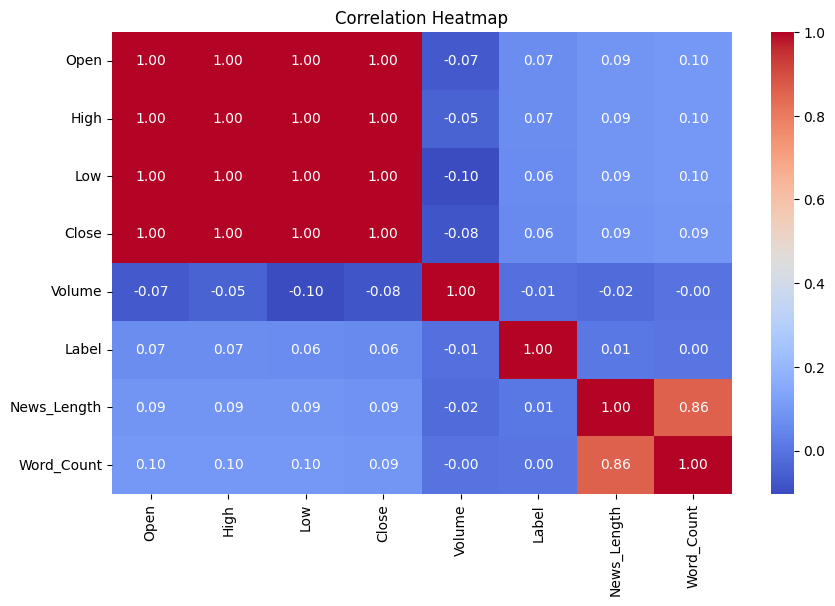

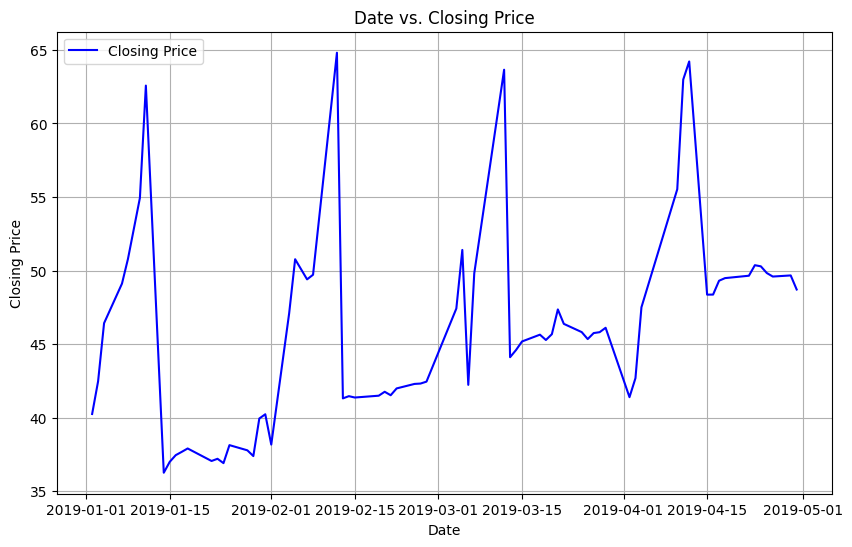

In [209]:
# Correlation Analysis
# Ensure 'Date' is in datetime format
# Define numeric_data by selecting numerical columns from the data DataFrame
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Plot the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Date vs. Closing Price
plt.figure(figsize=(10, 6))
plt.plot(data['Date'], data['Close'], label='Closing Price', color='blue')
plt.title('Date vs. Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid()
plt.show()

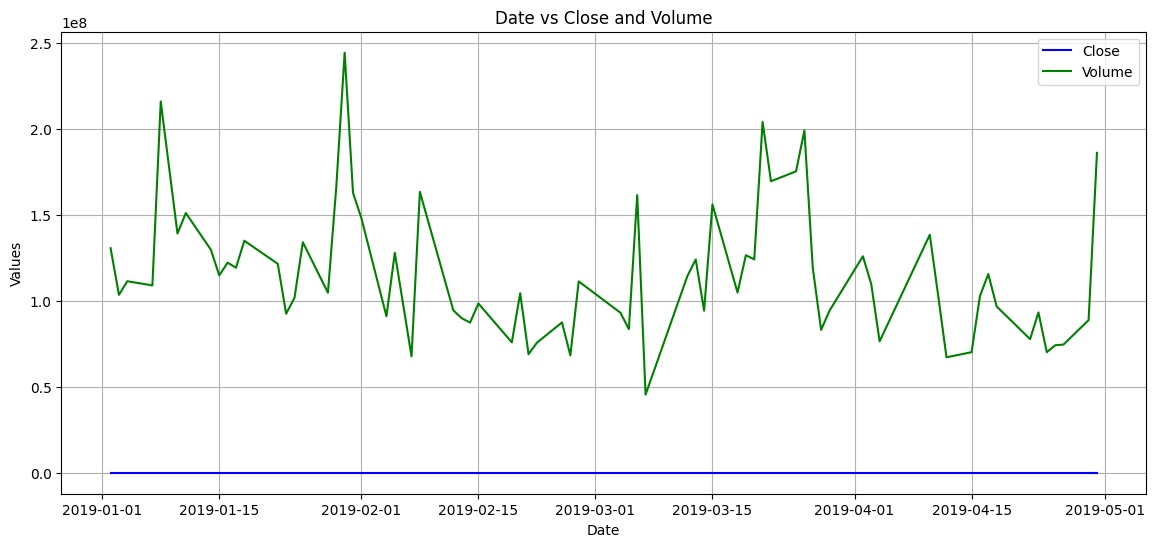

In [210]:

# Plotting line plots for 'Date' vs 'Close' and 'Date' vs 'Volume'
plt.figure(figsize=(14, 6))

# Line plot for 'Date' vs 'Close'
plt.plot(data['Date'], data['Close'], label='Close', color='blue')

# Line plot for 'Date' vs 'Volume'
plt.plot(data['Date'], data['Volume'], label='Volume', color='green')

# Adding title and labels
plt.title('Date vs Close and Volume')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.grid()

# Display the plot
plt.show()

## **Data Preprocessing**

#### Sort Date column, drop duplicates, Check for missing values and show Processed Data

In [211]:
# Sort the data by 'Date' to ensure chronological order
data = data.sort_values(by='Date').reset_index(drop=True)

# Check for duplicate rows and remove them if any
data = data.drop_duplicates()

# Check for missing values and handle them if necessary
if data.isnull().sum().sum() > 0:
    print("Missing values detected. Handling missing values...")
    data = data.fillna(method='ffill').fillna(method='bfill')

# Normalize the numerical columns for better analysis

scaler = MinMaxScaler()
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'News_Length']
data[numeric_columns] = scaler.fit_transform(data[numeric_columns])

# Display the processed data
print("Processed Data:")
print(data.head())

Processed Data:
        Date                                               News     Open  \
0 2019-01-02   The tech sector experienced a significant dec...  0.14265   
1 2019-01-02   The dollar fell from above 109 to 106.67 afte...  0.14265   
2 2019-01-02   In early Asian trading on Thursday, the Japan...  0.14265   
3 2019-01-02   The Australian dollar experienced significant...  0.14265   
4 2019-01-02   Apple Inc. lowered its quarterly sales foreca...  0.14265   

       High       Low     Close    Volume  Label  News_Length Sentiment_Label  \
0  0.151393  0.146284  0.139847  0.428282     -1     0.753521        Negative   
1  0.151393  0.146284  0.139847  0.428282     -1     0.489437        Negative   
2  0.151393  0.146284  0.139847  0.428282     -1     0.739437        Negative   
3  0.151393  0.146284  0.139847  0.428282      0     0.654930         Neutral   
4  0.151393  0.146284  0.139847  0.428282     -1     0.795775        Negative   

   Word_Count  
0          45  
1       

### Splitting the Data into Training, Validation, and Test Sets

In [212]:
# Splitting the data based on the specified date ranges
X_train = data[data['Date'] < '2019-03-15']
X_val = data[(data['Date'] >= '2019-03-15') & (data['Date'] < '2019-04-01')]
X_test = data[data['Date'] >= '2019-04-01']

# Displaying the shapes of the splits
print(f"Training Data Shape: {X_train.shape}")
print(f"Validation Data Shape: {X_val.shape}")
print(f"Test Data Shape: {X_test.shape}")

Training Data Shape: (240, 11)
Validation Data Shape: (46, 11)
Test Data Shape: (63, 11)


In [213]:
# Define the target variable
y_train = X_train['Label']
y_val = X_val['Label']
y_test = X_test['Label']

# Map the Label values to their corresponding sentiment labels
label_mapping = {-1: "Negative", 0: "Neutral", 1: "Positive"}
y_train = y_train.map(label_mapping)
y_val = y_val.map(label_mapping)
y_test = y_test.map(label_mapping)

# Display the first few rows of the target variable
print("Training Target Variable (y_train):")
print(y_train.head())

print("\nValidation Target Variable (y_val):")
print(y_val.head())

print("\nTest Target Variable (y_test):")
print(y_test.head())


Training Target Variable (y_train):
0    Negative
1    Negative
2    Negative
3     Neutral
4    Negative
Name: Label, dtype: object

Validation Target Variable (y_val):
240    Positive
241    Positive
242     Neutral
243     Neutral
244     Neutral
Name: Label, dtype: object

Test Target Variable (y_test):
286     Neutral
287     Neutral
288     Neutral
289    Negative
290     Neutral
Name: Label, dtype: object


In [214]:
X_train.head()

,Date,News,Open,High,Low,Close,Volume,Label,News_Length,Sentiment_Label,Word_Count
0,2019-01-02,The tech sector experienced a significant dec...,0.14265,0.151393,0.146284,0.139847,0.428282,-1,0.753521,Negative,45
1,2019-01-02,The dollar fell from above 109 to 106.67 afte...,0.14265,0.151393,0.146284,0.139847,0.428282,-1,0.489437,Negative,40
2,2019-01-02,"In early Asian trading on Thursday, the Japan...",0.14265,0.151393,0.146284,0.139847,0.428282,-1,0.739437,Negative,53
3,2019-01-02,The Australian dollar experienced significant...,0.14265,0.151393,0.146284,0.139847,0.428282,0,0.654930,Neutral,42
4,2019-01-02,Apple Inc. lowered its quarterly sales foreca...,0.14265,0.151393,0.146284,0.139847,0.428282,-1,0.795775,Negative,47


In [215]:
X_val.head()

,Date,News,Open,High,Low,Close,Volume,Label,News_Length,Sentiment_Label,Word_Count
240,2019-03-15,Stocks rallied Friday as technology companies...,0.295556,0.308258,0.302197,0.312525,0.556425,1,0.566901,Positive,40
241,2019-03-15,"In a SEC filing, Berkshire Hathaway revealed ...",0.295556,0.308258,0.302197,0.312525,0.556425,1,0.588028,Positive,40
242,2019-03-15,Apple and Spotify are in a dispute with EU an...,0.295556,0.308258,0.302197,0.312525,0.556425,0,0.725352,Neutral,52
243,2019-03-15,This year's China Central Television (CCTV) co...,0.295556,0.308258,0.302197,0.312525,0.556425,0,0.683099,Neutral,49
244,2019-03-15,Oracle stock declined by 8.15% in premarket t...,0.295556,0.308258,0.302197,0.312525,0.556425,0,0.457746,Neutral,39


In [216]:
X_test.head()

,Date,News,Open,High,Low,Close,Volume,Label,News_Length,Sentiment_Label,Word_Count
286,2019-04-02,"Apple and other consumer brands, including LV...",0.146496,0.174303,0.158102,0.179888,0.404711,0,0.549296,Neutral,44
287,2019-04-02,Swatch Group successfully defended its use of...,0.146496,0.174303,0.158102,0.179888,0.404711,0,0.778169,Neutral,46
288,2019-04-02,"In premarket trade Tuesday, Apple's NASDAQ AA...",0.146496,0.174303,0.158102,0.179888,0.404711,0,0.355634,Neutral,34
289,2019-04-02,"In US markets, futures for the Dow, S&P 500, ...",0.146496,0.174303,0.158102,0.179888,0.404711,-1,0.510563,Negative,46
290,2019-04-03,"In the first quarter, Samsung Electronics fac...",0.217265,0.226363,0.216668,0.225213,0.323114,0,0.866197,Neutral,51


In [217]:
y_train.head()

0    Negative
1    Negative
2    Negative
3     Neutral
4    Negative
Name: Label, dtype: object

## **Word Embeddings**

In [218]:
# Tokenize the News column into a list of words
news_sentences = data['News'].apply(lambda x: x.split()).tolist()

# Create an instance of Word2Vec
word2vec_model = Word2Vec(sentences=news_sentences, vector_size=100, window=5, min_count=1, workers=4, sg=0)

# Display the size of the vocabulary
print(f"Vocabulary size: {len(word2vec_model.wv.index_to_key)}")

Vocabulary size: 4681


In [219]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(word2vec_model.wv.key_to_index.keys())
print(words[:10])  # Display the first 10 words

['and', 'the', 'to', 'a', 'in', 'The', 'of', 'for', 'on', 'with']


In [220]:
word2vec_model.wv["revenue"]

array([-0.08125437,  0.09732312,  0.05655491,  0.01826067,  0.02453561,
       -0.12298438,  0.05444786,  0.229259  , -0.05949353, -0.06001813,
       -0.01305974, -0.16494761, -0.00718448,  0.04221229,  0.03250701,
       -0.07359847,  0.01992499, -0.08865356, -0.02330807, -0.19899268,
        0.03709047,  0.03753691,  0.0921561 , -0.04595704, -0.01923286,
        0.00071586, -0.07184183, -0.02755622, -0.07775545,  0.0278131 ,
        0.13784462, -0.00087235,  0.04473749, -0.11576913, -0.02994083,
        0.12553719,  0.03223931, -0.03748808, -0.02511663, -0.12130647,
        0.02166428, -0.11302651, -0.08577456,  0.01761118,  0.0873879 ,
       -0.06369101, -0.09050065, -0.02577247,  0.06942941,  0.04097182,
        0.07055863, -0.09538064, -0.00803125, -0.02514617, -0.06470837,
        0.06165766,  0.08736531, -0.01533367, -0.10615688,  0.02097905,
       -0.00491181, -0.00943604,  0.00273798,  0.01525255, -0.10927109,
        0.08650466,  0.05397696,  0.07315689, -0.13741788,  0.13

In [221]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(word2vec_model.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = word2vec_model.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

print("Length of the dictionary is ", len(word_vector_dict))

Length of the dictionary is  4681


In [222]:
# Keep only the first 100 words
vec_size=100

def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [223]:
# Creating a dataframe of the vectorized documents
X_train_wv = pd.DataFrame(X_train["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_wv = pd.DataFrame(X_val["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_wv = pd.DataFrame(X_test["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
print(X_train_wv.shape, X_val_wv.shape, X_test_wv.shape)


(240, 100) (46, 100) (63, 100)


#### Glove

In [224]:
from gensim.models import KeyedVectors
import numpy as np

# Load the GloVe embeddings
glove_file_path = r"D:\Dev\AI-ML-Project-Data\NLP-Project\glove.6B.100d.txt.word2vec"
glove_model = KeyedVectors.load_word2vec_format(glove_file_path, binary=False)



In [225]:
# Retrieving the words present in the GloVe model's vocabulary
glove_words = glove_model.index_to_key

# Creating a dictionary of words and their corresponding vectors
glove_word_vector_dict = dict(zip(glove_model.index_to_key,list(glove_model.vectors)))

In [226]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(glove_word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [227]:
X_train_gl = pd.DataFrame(X_train["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column
X_val_gl = pd.DataFrame(X_val["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column
X_test_gl = pd.DataFrame(X_test["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)]) #Complete the code to apply GloVe on 'News' column

In [228]:
# Print the shapes of the final dataframes
print(X_train_gl.shape, X_val_gl.shape, X_test_gl.shape) 

(240, 100) (46, 100) (63, 100)


#### Check Embeddings

In [229]:
# Checking the word embedding of a random word
glove_model["revenue"]

array([ 0.17132  , -0.042936 ,  0.48587  , -0.49912  ,  0.83222  ,
       -0.79533  , -0.39641  ,  0.0059214,  0.065537 , -0.35212  ,
        0.40528  , -0.12115  , -0.15325  , -0.46874  ,  0.2268   ,
       -0.80513  ,  0.065305 ,  0.25888  ,  0.4961   ,  1.0646   ,
        0.14317  ,  0.11955  , -0.35765  ,  1.0962   , -0.57384  ,
       -0.62014  ,  0.54423  , -0.20712  , -0.67822  , -0.82173  ,
        0.6037   ,  0.26209  , -0.18882  , -0.90291  , -0.181    ,
        0.43017  , -0.30814  ,  0.15839  , -0.0065962, -0.20375  ,
        0.52302  , -0.75001  , -0.35737  ,  0.38933  ,  0.2421   ,
       -0.1404   , -0.19481  , -0.97056  , -0.169    , -1.1695   ,
        0.089281 , -0.098044 ,  0.5469   ,  0.888    ,  0.42843  ,
       -1.8364   ,  0.083037 , -0.59659  ,  2.2736   ,  0.21042  ,
        0.21198  , -1.0437   , -0.66913  ,  0.5043   , -0.44588  ,
       -0.025209 , -0.1372   , -0.15207  ,  1.482    , -0.17329  ,
        0.69726  , -0.10271  ,  0.37622  , -0.016729 ,  0.1806

### Sentence Transformer

#### Define Sentence Transformer Model

In [230]:
# Load the SentenceTransformer model
sentence_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Example usage: Encode a sample sentence
sample_sentence = "The stock market showed significant growth today."
sentence_embedding = sentence_model.encode(sample_sentence)

# Print the shape of the embedding
print(f"Shape of the sentence embedding: {sentence_embedding.shape}")

Shape of the sentence embedding: (384,)


##### Encode Dataset

In [231]:
import torch

# Check if CUDA is available
if torch.cuda.is_available():
    device = torch.device("cuda:0")  # Use GPU
    print("CUDA is available. Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")  # Fallback to CPU
    print("CUDA is not available. Using CPU.")

# Set the device
torch.cuda.set_device(device)



CUDA is available. Using GPU: NVIDIA GeForce RTX 3060


In [232]:
# Encode the 'News' column using the SentenceTransformer model
X_train_encoded = pd.DataFrame(sentence_model.encode(X_train['News'].tolist()), columns=[f'Feature_{i}' for i in range(sentence_embedding.shape[0])])
X_val_encoded = pd.DataFrame(sentence_model.encode(X_val['News'].tolist()), columns=[f'Feature_{i}' for i in range(sentence_embedding.shape[0])])
X_test_encoded = pd.DataFrame(sentence_model.encode(X_test['News'].tolist()), columns=[f'Feature_{i}' for i in range(sentence_embedding.shape[0])])

# Display the shapes of the encoded datasets
print(f"Encoded Training Data Shape: {X_train_encoded.shape}")
print(f"Encoded Validation Data Shape: {X_val_encoded.shape}")
print(f"Encoded Test Data Shape: {X_test_encoded.shape}")

Encoded Training Data Shape: (240, 384)
Encoded Validation Data Shape: (46, 384)
Encoded Test Data Shape: (63, 384)


## **Sentiment Analysis**

In [233]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import pandas as pd

def compute_classification_metrics(model, predictors, target):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """
    # Make predictions
    predictions = model.predict(predictors)
    
    # Compute metrics
    metrics = {
        "Accuracy": accuracy_score(target, predictions),
        "Recall": recall_score(target, predictions, average='weighted'),
        "Precision": precision_score(target, predictions, average='weighted'),
        "F1-score": f1_score(target, predictions, average='weighted')
    }
    
    # Convert metrics to a DataFrame
    metrics_df = pd.DataFrame([metrics])
    
    return metrics_df

In [234]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

def plot_confusion_matrix(actual, predicted, class_names):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.
    class_names (list): List of class names corresponding to the labels.

    Displays the confusion matrix plot.
    """
    # Compute the confusion matrix
    cm = confusion_matrix(actual, predicted)

    # Create a heatmap for the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

##### Base Model - Word2Vec

In [235]:
# Other classfiers tried earlier
#base_wv = DecisionTreeClassifier(random_state=42)
#base_wv = GradientBoostingClassifier(random_state=42)
#base_wv = RandomForestClassifier(random_state=42)
from sklearn.ensemble import AdaBoostClassifier
base_wv = AdaBoostClassifier(random_state=42)

# Fitting on train data
base_wv.fit(X_train_wv, y_train)

AdaBoostClassifier(random_state=42)

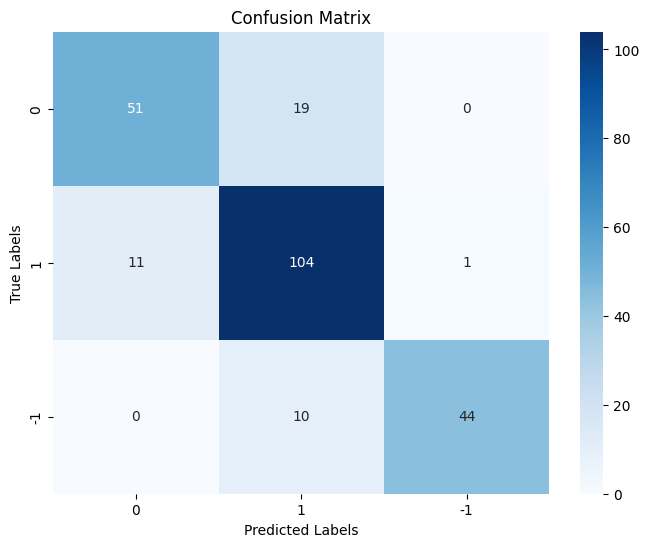

In [236]:
pred = base_wv.predict(X_train_wv)  # Make predictions using the classifier.
label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
plot_confusion_matrix(y_train, pred,label_list)

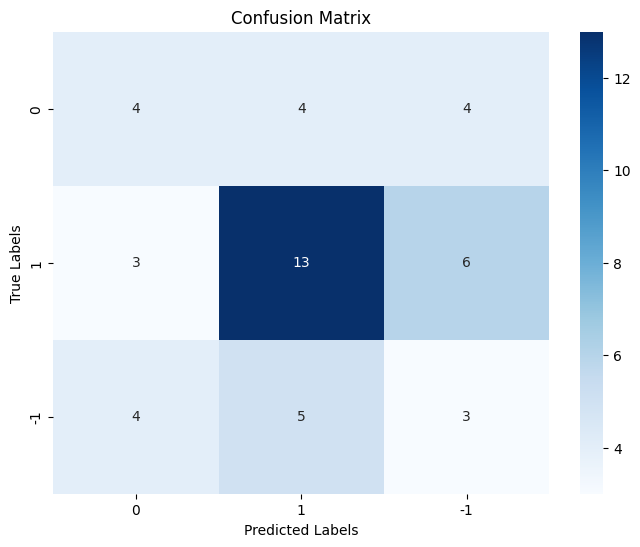

In [237]:
pred = base_wv.predict(X_val_wv)  # Make predictions using the classifier.
label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
plot_confusion_matrix(y_val, pred, label_list)

In [238]:
# Calculating different metrics on training data
base_train_wv = compute_classification_metrics(base_wv,X_train_wv,y_train)
print("Training performance:\n", base_train_wv)

Training performance:
    Accuracy    Recall  Precision  F1-score
0  0.829167  0.829167   0.837864  0.829127


In [239]:
# Calculating different metrics on validation data
base_val_wv = compute_classification_metrics(base_wv,X_val_wv,y_val)
print("Validation performance:\n",base_val_wv)

Validation performance:
    Accuracy    Recall  Precision  F1-score
0  0.434783  0.434783   0.437671  0.435955


##### Base Mode - GloVe

In [240]:
# Other classfiers tried earlier
#base_wv = DecisionTreeClassifier(random_state=42)
#base_wv = GradientBoostingClassifier(random_state=42)
#base_wv = RandomForestClassifier(random_state=42)
from sklearn.ensemble import AdaBoostClassifier
base_gl = AdaBoostClassifier(random_state=42)

# Fitting on train data
base_gl.fit(X_train_gl, y_train) #Complete the code to fit the chosen model on the train data

AdaBoostClassifier(random_state=42)

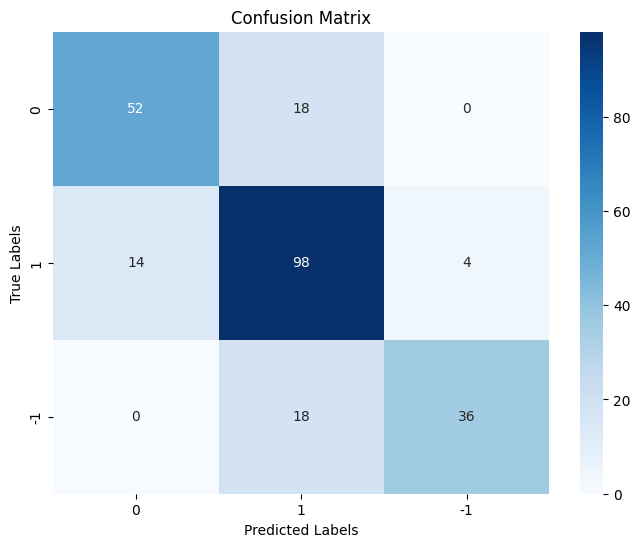

In [241]:
# Plot the confusion matrix for the train data

pred = base_gl.predict(X_train_gl)  # Make predictions using the classifier.
label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
plot_confusion_matrix(y_train, pred, label_list)

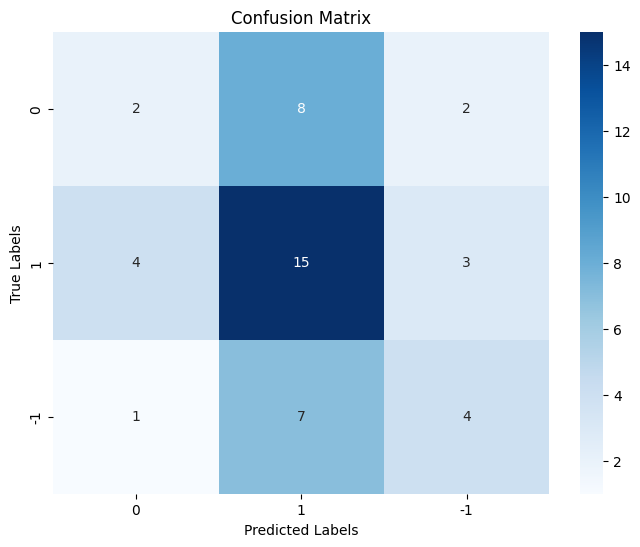

In [242]:
# Plot the confusion matrix for the validation data
pred = base_gl.predict(X_val_gl)  # Make predictions using the classifier.
plot_confusion_matrix(y_val, pred, label_list)

In [243]:
 #Calculating different metrics on training data

# Compute the model performance for the training data
base_train_gl = compute_classification_metrics(base_gl,X_train_gl,y_train)
print("Training performance:\n", base_train_gl)

Training performance:
    Accuracy  Recall  Precision  F1-score
0     0.775   0.775   0.785781  0.774313


In [244]:
# Calculating different metrics on validation data

# Compute the model performance for the validation data
base_val_gl = compute_classification_metrics(base_gl,X_val_gl,y_val) 
print("Validation performance:\n",base_val_gl)

Validation performance:
    Accuracy    Recall  Precision  F1-score
0  0.456522  0.456522   0.429607  0.430219


#### Base Model - Sentence Transformer

In [245]:
# Other classfiers tried earlier
#base_wv = DecisionTreeClassifier(random_state=42)
#base_wv = GradientBoostingClassifier(random_state=42)
#base_wv = RandomForestClassifier(random_state=42)
from sklearn.ensemble import AdaBoostClassifier
base_st = AdaBoostClassifier(random_state=42)

# Fitting on train data
base_st.fit(X_train_encoded, y_train) #Complete the code to fit the chosen model on the train data

AdaBoostClassifier(random_state=42)

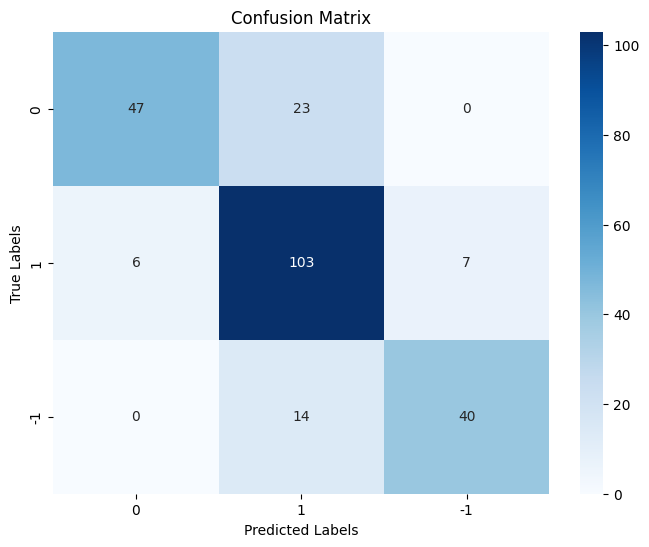

In [246]:
# Plot the confusion matrix for the train data
pred = base_st.predict(X_train_encoded)  # Make predictions using the classifier.
plot_confusion_matrix(y_train, pred, label_list)

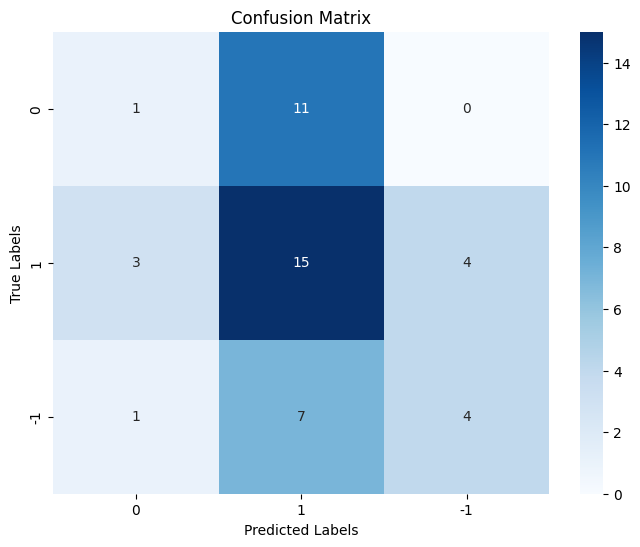

In [247]:
# Plot the confusion matrix for the validation data
pred = base_st.predict(X_val_encoded)  # Make predictions using the classifier.
plot_confusion_matrix(y_val, pred, label_list)

In [248]:
# Calculating different metrics on training data

# Compute the model performance for the training data
base_train_st = compute_classification_metrics(base_st,X_train_encoded,y_train) 
print("Validation performance:\n",base_train_st)

Validation performance:
    Accuracy    Recall  Precision  F1-score
0  0.791667  0.791667   0.805732   0.79005


In [249]:
#Calculating different metrics on validation data

# Compute the model performance for the validation data
base_val_st = compute_classification_metrics(base_st,X_val_encoded,y_val) 
print("Validation performance:\n",base_val_st)

Validation performance:
    Accuracy    Recall  Precision  F1-score
0  0.434783  0.434783        0.4  0.395908


#### Tuned Model - Word2Vec

In [250]:
# Other classfiers tried earlier
#base_wv = DecisionTreeClassifier(random_state=42)
#base_wv = GradientBoostingClassifier(random_state=42)
#base_wv = RandomForestClassifier(random_state=42)
from sklearn.ensemble import AdaBoostClassifier
tuned_wv = AdaBoostClassifier(random_state=42)

parameters = {
#    'max_depth': np.arange(3,7),
#    'min_samples_split': np.arange(5,12,2),
#    'max_features': ['log2', 'sqrt', 0.2, 0.4]
#}

# AdaBoostClassifier parameters
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_wv, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_wv, y_train)

# Set the clf to the best combination of parameters
tuned_wv = grid_obj.best_estimator_

In [251]:
# Fit the best algorithm to the data.
tuned_wv.fit(X_train_wv, y_train)

AdaBoostClassifier(learning_rate=0.1, n_estimators=200, random_state=42)

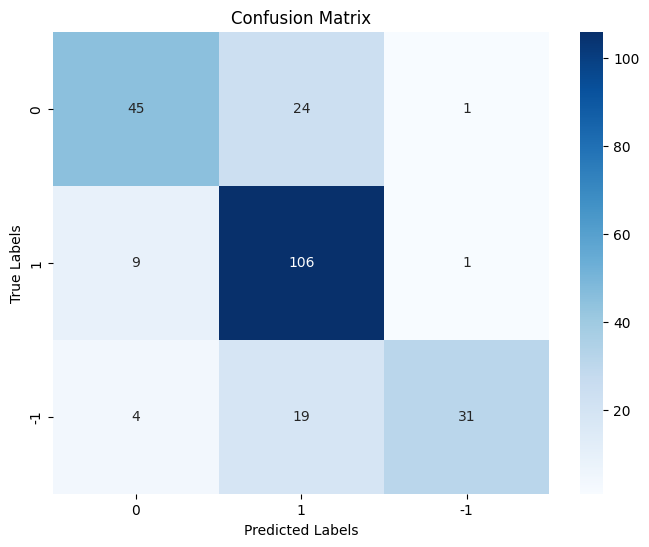

In [252]:
# Plot the confusion matrix for the training data
pred = tuned_wv.predict(X_train_wv)  # Make predictions using the classifier.
plot_confusion_matrix(y_train, pred, label_list)

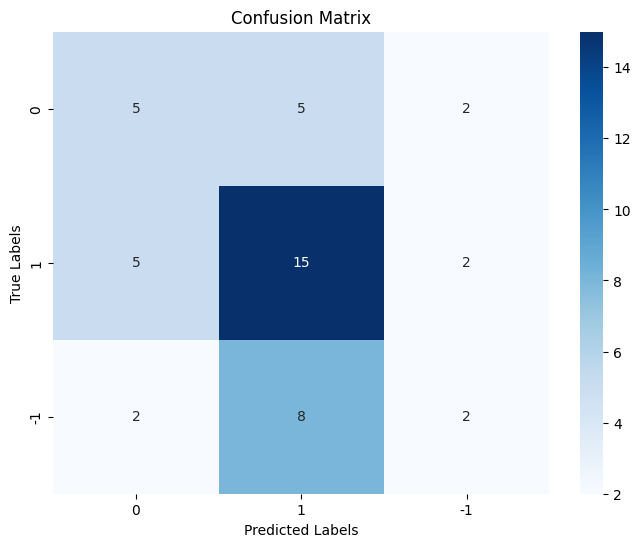

In [253]:
# Plot the confusion matrix for the validation data
pred = tuned_wv.predict(X_val_wv)  # Make predictions using the classifier.
plot_confusion_matrix(y_val, pred, label_list)

In [254]:
#Calculating different metrics on training data
tuned_train_wv=compute_classification_metrics(tuned_wv,X_train_wv,y_train)
print("Training performance:\n",tuned_train_wv)

Training performance:
    Accuracy    Recall  Precision  F1-score
0  0.758333  0.758333   0.781505   0.75209


In [255]:
#Calculating different metrics on validation data
tuned_val_wv = compute_classification_metrics(tuned_wv,X_val_wv,y_val)
print("Validation performance:\n",tuned_val_wv)

Validation performance:
    Accuracy    Recall  Precision  F1-score
0  0.478261  0.478261   0.451863  0.453623


#### Tuned Model - GloVe

In [256]:
# Other classfiers tried earlier
#base_wv = DecisionTreeClassifier(random_state=42)
#base_wv = GradientBoostingClassifier(random_state=42)
#base_wv = RandomForestClassifier(random_state=42)
from sklearn.ensemble import AdaBoostClassifier
tuned_gl = AdaBoostClassifier(random_state=42)

parameters = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}
# Run the grid search

# Complete the code to pass the chosen model, parameters, scoring metric, and number of 
# cross-validation folds to GridSearchCV
grid_obj = GridSearchCV(tuned_gl, parameters, scoring='f1_weighted',cv=5,n_jobs=-1) 
grid_obj = grid_obj.fit(X_train_gl, y_train)

# Set the clf to the best combination of parameters
tuned_gl = grid_obj.best_estimator_

In [257]:
# Fit the best algorithm to the data.
# Fit the chosen model on the train data
tuned_gl.fit(X_train_gl, y_train) 

AdaBoostClassifier(n_estimators=200, random_state=42)

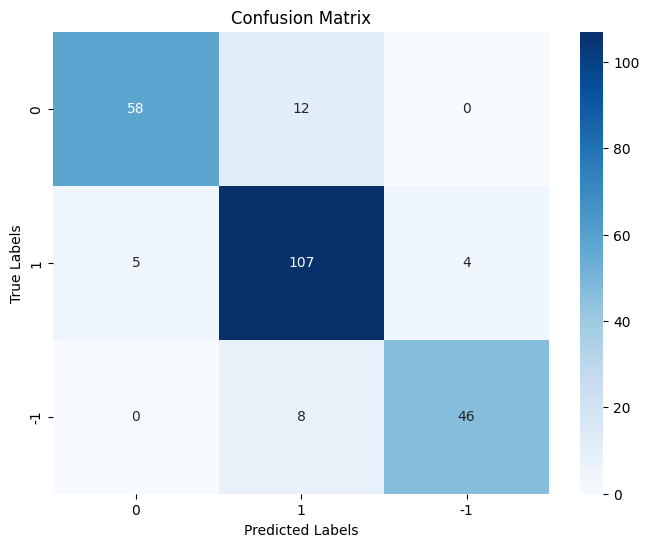

In [258]:
# Plot the confusion matrix for the train data
pred = tuned_gl.predict(X_train_gl)  # Make predictions using the classifier.
plot_confusion_matrix(y_train,pred, label_list) 

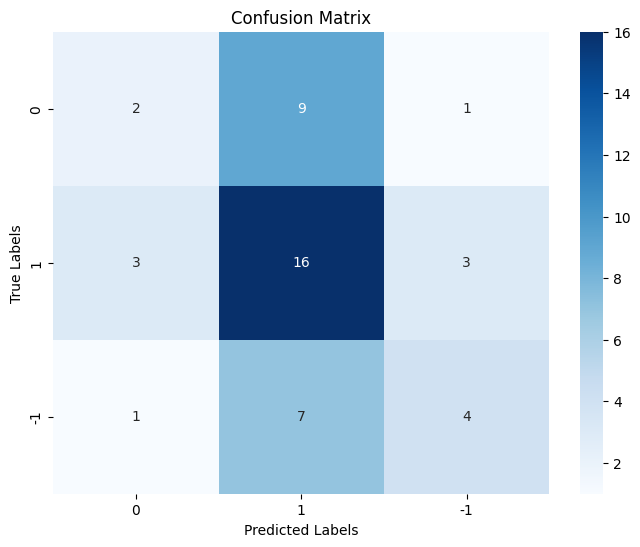

In [259]:
# Plot the confusion matrix for the validation data
pred = tuned_gl.predict(X_val_gl)  # Make predictions using the classifier.
plot_confusion_matrix(y_val,pred, label_list) 

In [260]:
#Calculating different metrics on training data

# Compute the model performance for the training data
tuned_train_gl=compute_classification_metrics(tuned_gl,X_train_gl,y_train) 
print("Training performance:\n",tuned_train_gl)

Training performance:
    Accuracy    Recall  Precision  F1-score
0  0.879167  0.879167   0.882736  0.879076


In [261]:
#Calculating different metrics on validation data

# Compute the model performance for the validation data
tuned_val_gl = compute_classification_metrics(tuned_gl,X_val_gl,y_val) 
print("Validation performance:\n",tuned_val_gl)

Validation performance:
    Accuracy    Recall  Precision  F1-score
0  0.478261  0.478261   0.456522  0.445733


#### Tuned Model - Sentence Transformer

In [262]:
# Other classfiers tried earlier
#base_wv = DecisionTreeClassifier(random_state=42)
#base_wv = GradientBoostingClassifier(random_state=42)
#base_wv = RandomForestClassifier(random_state=42)
from sklearn.ensemble import AdaBoostClassifier
tuned_st = AdaBoostClassifier(random_state=42)

parameters = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}
# Run the grid search
#Complete the code to pass the chosen model
grid_obj = GridSearchCV(tuned_st, parameters, scoring='f1_weighted',cv=5,n_jobs=-1) 
grid_obj = grid_obj.fit(X_train_encoded, y_train)

# Set the clf to the best combination of parameters
tuned_st = grid_obj.best_estimator_

In [263]:
# Fit the best algorithm to the data.
# Fit the chosen model on the train data
tuned_st.fit(X_train_encoded, y_train) 

AdaBoostClassifier(random_state=42)

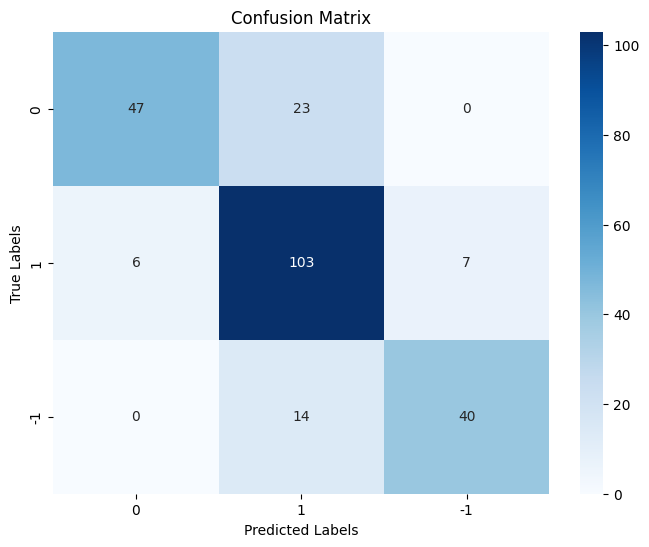

In [264]:
# Plot the confusion matrix for the train data
pred = tuned_st.predict(X_train_encoded)  # Make predictions using the classifier.
plot_confusion_matrix(y_train, pred, label_list)

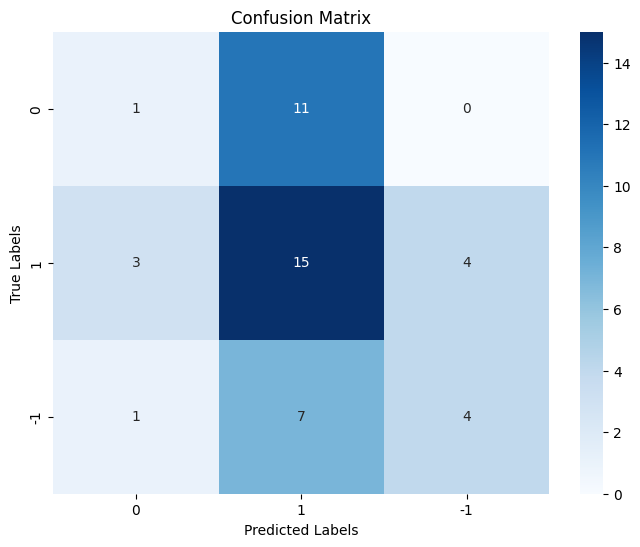

In [265]:
# Plot the confusion matrix for the validation data
pred = tuned_st.predict(X_val_encoded)  # Make predictions using the classifier.
plot_confusion_matrix(y_val, pred, label_list)

In [266]:
#Calculating different metrics on training data
# Compute the model performance for the training data
tuned_train_st=compute_classification_metrics(tuned_st,X_train_encoded,y_train) 
print("Training performance:\n",tuned_train_st)

Training performance:
    Accuracy    Recall  Precision  F1-score
0  0.791667  0.791667   0.805732   0.79005


In [267]:
#Calculating different metrics on validation data
# Compute the model performance for the validation data
tuned_val_st = compute_classification_metrics(tuned_st,X_val_encoded,y_val) 
print("Validation performance:\n",tuned_val_st)

Validation performance:
    Accuracy    Recall  Precision  F1-score
0  0.434783  0.434783        0.4  0.395908


In [268]:
# Consolidate training performance metrics for all models
training_performance = pd.DataFrame({
    "Model": ["Base Word2Vec", "Base GloVe", "Base Sentence Transformer", 
              "Tuned Word2Vec", "Tuned GloVe", "Tuned Sentence Transformer"],
    "Accuracy": [base_train_wv["Accuracy"].iloc[0], base_train_gl["Accuracy"].iloc[0], base_train_st["Accuracy"].iloc[0],
                 tuned_train_wv["Accuracy"].iloc[0], tuned_train_gl["Accuracy"].iloc[0], tuned_train_st["Accuracy"].iloc[0]],
    "Recall": [base_train_wv["Recall"].iloc[0], base_train_gl["Recall"].iloc[0], base_train_st["Recall"].iloc[0],
               tuned_train_wv["Recall"].iloc[0], tuned_train_gl["Recall"].iloc[0], tuned_train_st["Recall"].iloc[0]],
    "Precision": [base_train_wv["Precision"].iloc[0], base_train_gl["Precision"].iloc[0], base_train_st["Precision"].iloc[0],
                  tuned_train_wv["Precision"].iloc[0], tuned_train_gl["Precision"].iloc[0], tuned_train_st["Precision"].iloc[0]],
    "F1-score": [base_train_wv["F1-score"].iloc[0], base_train_gl["F1-score"].iloc[0], base_train_st["F1-score"].iloc[0],
                 tuned_train_wv["F1-score"].iloc[0], tuned_train_gl["F1-score"].iloc[0], tuned_train_st["F1-score"].iloc[0]]
})

# Display the training performance comparison
print("Training Performance Comparison:")
print(training_performance)

Training Performance Comparison:
                        Model  Accuracy    Recall  Precision  F1-score
0               Base Word2Vec  0.829167  0.829167   0.837864  0.829127
1                  Base GloVe  0.775000  0.775000   0.785781  0.774313
2   Base Sentence Transformer  0.791667  0.791667   0.805732  0.790050
3              Tuned Word2Vec  0.758333  0.758333   0.781505  0.752090
4                 Tuned GloVe  0.879167  0.879167   0.882736  0.879076
5  Tuned Sentence Transformer  0.791667  0.791667   0.805732  0.790050


In [269]:
# Consolidate validation performance metrics for all models
validation_performance = pd.DataFrame({
    "Model": ["Base Word2Vec", "Base GloVe", "Base Sentence Transformer", 
              "Tuned Word2Vec", "Tuned GloVe", "Tuned Sentence Transformer"],
    "Accuracy": [base_val_wv["Accuracy"].iloc[0], base_val_gl["Accuracy"].iloc[0], base_val_st["Accuracy"].iloc[0],
                 tuned_val_wv["Accuracy"].iloc[0], tuned_val_gl["Accuracy"].iloc[0], tuned_val_st["Accuracy"].iloc[0]],
    "Recall": [base_val_wv["Recall"].iloc[0], base_val_gl["Recall"].iloc[0], base_val_st["Recall"].iloc[0],
               tuned_val_wv["Recall"].iloc[0], tuned_val_gl["Recall"].iloc[0], tuned_val_st["Recall"].iloc[0]],
    "Precision": [base_val_wv["Precision"].iloc[0], base_val_gl["Precision"].iloc[0], base_val_st["Precision"].iloc[0],
                  tuned_val_wv["Precision"].iloc[0], tuned_val_gl["Precision"].iloc[0], tuned_val_st["Precision"].iloc[0]],
    "F1-score": [base_val_wv["F1-score"].iloc[0], base_val_gl["F1-score"].iloc[0], base_val_st["F1-score"].iloc[0],
                 tuned_val_wv["F1-score"].iloc[0], tuned_val_gl["F1-score"].iloc[0], tuned_val_st["F1-score"].iloc[0]]
})

# Display the validation performance comparison
print("Validation Performance Comparison:")
print(validation_performance)

Validation Performance Comparison:
                        Model  Accuracy    Recall  Precision  F1-score
0               Base Word2Vec  0.434783  0.434783   0.437671  0.435955
1                  Base GloVe  0.456522  0.456522   0.429607  0.430219
2   Base Sentence Transformer  0.434783  0.434783   0.400000  0.395908
3              Tuned Word2Vec  0.478261  0.478261   0.451863  0.453623
4                 Tuned GloVe  0.478261  0.478261   0.456522  0.445733
5  Tuned Sentence Transformer  0.434783  0.434783   0.400000  0.395908


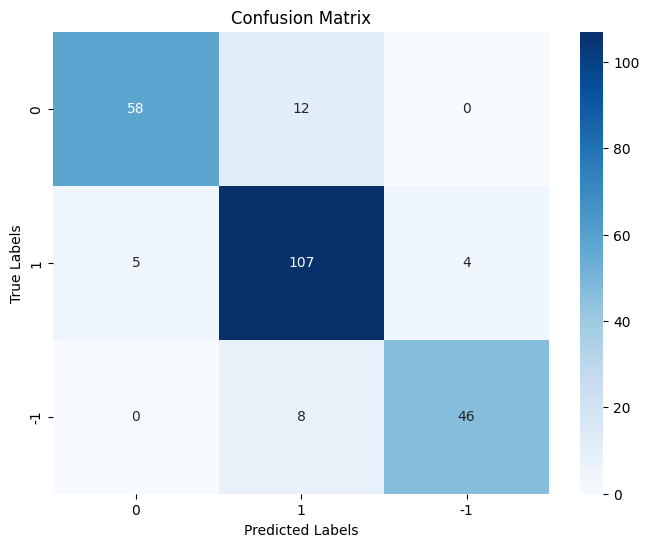

In [270]:
# Plot the confusion matrix for the train data
pred = tuned_gl.predict(X_train_gl)  # Make predictions using the classifier.
plot_confusion_matrix(y_train, pred, label_list) 

In [271]:
#Calculating different metrics on training data
final_model_test = compute_classification_metrics(tuned_gl,X_train_gl,y_train) #Complete the code to compute the final model's performance for the test data
print("Test performance for the final model:\n",final_model_test)

Test performance for the final model:
    Accuracy    Recall  Precision  F1-score
0  0.879167  0.879167   0.882736  0.879076


### Model Summary: Training and Validation Performance

#### Models Evaluated:
- **GradientBoostingClassifier**
- **RandomForestClassifier**
- **DecisionTreeClassifier**
- **AdaBoostClassifier**

#### Final Model:
- **AdaBoostClassifier with Tuned GloVe embeddings** was selected as the final model based on its superior performance.

## **Weekly News Summarization**

**Important Note**: It is recommended to run this section of the project independently from the previous sections in order to avoid runtime crashes due to RAM overload.

#### Installing and Importing the necessary libraries

In [272]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
# -- !CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python -q
# Instead use command line and install - 
#######################################
#set CMAKE_ARGS="-DLLAMA_CUBLAS=on"
#pip install llama-cpp-python
#pip install langchain
#pip install langchain.llm
#######################################
# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
#!CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python -q

In [273]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

from tqdm import tqdm # For progress bar related functionalities
tqdm.pandas()

#### Loading the data

In [274]:
# Load dataset.
stock_news = pd.read_csv(r"D:\Dev\AI-ML-Project-Data\NLP-Project/stock_news.csv")
stock_data = stock_news.copy()

#### Loading the model

In [275]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"

try:
    model_path = hf_hub_download(
        repo_id=model_name_or_path,  
        filename=model_basename 
    )
    print(f"Model downloaded successfully and saved at {model_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Model downloaded successfully and saved at C:\Users\Piyush\.cache\huggingface\hub\models--TheBloke--Mistral-7B-Instruct-v0.2-GGUF\snapshots\3a6fbf4a41a1d52e415a4958cde6856d34b2db93\mistral-7b-instruct-v0.2.Q6_K.gguf


In [276]:
#uncomment the below snippet of code if the runtime is connected to GPU.
llm = Llama(
    model_path=model_path, # Path to the model
    n_gpu_layers=100, #Number of layers transferred to GPU
    n_ctx=4500 ) #, #Context window
    #n_batch=512, #Batch size)

llama_model_loader: loaded meta data with 24 key-value pairs and 291 tensors from C:\Users\Piyush\.cache\huggingface\hub\models--TheBloke--Mistral-7B-Instruct-v0.2-GGUF\snapshots\3a6fbf4a41a1d52e415a4958cde6856d34b2db93\mistral-7b-instruct-v0.2.Q6_K.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = mistralai_mistral-7b-instruct-v0.2
llama_model_loader: - kv   2:                       llama.context_length u32              = 32768
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 14336
llama_m

#### Aggregating the data weekly

In [277]:
stock_data["Date"] = pd.to_datetime(data['Date'])  # Convert the 'Date' column to datetime format.

In [278]:
# Group the data by week using the 'Date' column.
weekly_grouped = stock_data.groupby(pd.Grouper(key='Date', freq='W'))

In [279]:
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

(18, 2)


In [280]:
weekly_grouped

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an..."
6,2019-02-17,"This week, the European Union's second highes..."
7,2019-02-24,This news article discusses progress towards ...
8,2019-03-03,The Dow Jones Industrial Average and other ma...
9,2019-03-10,"Spotify, the world's largest paid music strea..."


In [281]:
# creating a copy of the data
data_1 = weekly_grouped.copy()

#### Summarization

**Note**:

- The model is expected to summarize the news from the week by identifying the top three positive and negative events that are most likely to impact the price of the stock.

- As an output, the model is expected to return a JSON containing two keys, one for Positive Events and one for Negative Events.

For the project, we need to define the prompt to be fed to the LLM to help it understand the task to perform. The following should be the components of the prompt:

1. **Role**: Specifies the role the LLM will be taking up to perform the specified task, along with any specific details regarding the role

  - **Example**: `You are an expert data analyst specializing in news content analysis.`

2. **Task**: Specifies the task to be performed and outlines what needs to be accomplished, clearly defining the objective

  - **Example**: `Analyze the provided news headline and return the main topics contained within it.`

3. **Instructions**: Provides detailed guidelines on how to perform the task, which includes steps, rules, and criteria to ensure the task is executed correctly

  - **Example**:

```
Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.
```

4. **Output Format**: Specifies the format in which the final response should be structured, ensuring consistency and clarity in the generated output

  - **Example**: `Return the output in JSON format with keys as the topic number and values as the actual topic.`

**Full Prompt Example**:

```
You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
```

**Sample Output**:

`{"1": "Politics", "2": "Economy", "3": "Health" }`

##### Utility Functions

In [312]:
# defining a function to parse the JSON output from the model
def extract_json_data(json_str):
    import json
    try:
        # Find the indices of the opening and closing curly braces
        json_start = json_str.find('{')
        json_end = json_str.rfind('}')

        if json_start != -1 and json_end != -1:
            extracted_category = json_str[json_start:json_end + 1]  # Extract the JSON object
            data_dict = json.loads(extracted_category)
            return data_dict
        else:
            print(f"Warning: JSON object not found in response: {json_str}")
            return {}
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return {}    

##### Defining the response function

In [284]:
#Defining the response function
def response_mistral_1(prompt, news):
    model_output = llm(
      f"""
      [INST]
      {prompt}
      News Articles: {news}
      [/INST]
      """,
      max_tokens=1024,      # Set the maximum number of tokens the model should generate for this task.
      temperature=0.7,     # Set the value for temperature.
      top_p=0.9,           # Set the value for top_p.
      top_k=50,            # Set the value for top_k.
      echo=False,
    )

    final_output = model_output["choices"][0]["text"]

    return final_output

##### Checking the model output on a sample

**Note**: Use this section to test out the prompt with one instance before using it for the entire weekly data.

In [285]:
news = data_1.loc[0, 'News']

In [286]:
print(len(news.split(' ')))
news

2611


' The tech sector experienced a significant decline in the aftermarket following Apple\'s Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple\'s downward revision of its revenue expectations for the quarter, previously announced in January. ||  Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple\'s stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10 ||  Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple\'s shares fell 8.5% in post market trading, while Asian suppliers like Hon ||  This news article reports that yields o

In [287]:
print("Columns in model_response_parsed:", data_1.columns)

Columns in model_response_parsed: Index(['Date', 'News'], dtype='object')


In [288]:
prompt = """
You are an expert data analyst specializing in stock market news article analysis that affects the financial market.
Task: Analyze the news headlines and determine which news articles are positive or negative in sentiment.
Instructions:
1. Read the individual news article that is separated by ' || '. 
2. Identify if the article contains positive or negative sentiment based on optimistic or pessimistic indicators. 
2. Extract each article and create a summary based on the sentiment (Positive or Negative).
2. Summarize results by grouping by date into weeks, include the individual news articles and count the number of Positive (1) and Negative (-1) sentiments. 
Output the results in JSON format.
"""

In [289]:
%%time
summary = response_mistral_1(prompt, news)
print(summary)

llama_perf_context_print:        load time =   97348.24 ms
llama_perf_context_print: prompt eval time =   97347.97 ms /  3921 tokens (   24.83 ms per token,    40.28 tokens per second)
llama_perf_context_print:        eval time =   66357.69 ms /   590 runs   (  112.47 ms per token,     8.89 tokens per second)
llama_perf_context_print:       total time =  164094.49 ms /  4511 tokens


 {
         "Week_1_January_2019": {
           "News_Articles": [
             "Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales.",
             "This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown."
           ],
           "Sentiment": "Negative",
           "Number_of_Articles": 2
         },
         "Week_2_January_2019": {
           "News_Articles": [
             "Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency.",
             "Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggere

##### Checking the model output on the weekly data

In [290]:
%%time
data_1['Key Events'] = data_1['News'].progress_apply(lambda x: response_mistral_1(prompt,x))

  0%|          | 0/18 [00:00<?, ?it/s]Llama.generate: 3920 prefix-match hit, remaining 1 prompt tokens to eval
llama_perf_context_print:        load time =   97348.24 ms
llama_perf_context_print: prompt eval time =       0.00 ms /     1 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =   67491.55 ms /   591 runs   (  114.20 ms per token,     8.76 tokens per second)
llama_perf_context_print:       total time =   67901.98 ms /   592 tokens
 11%|█         | 2/18 [01:07<09:03, 33.96s/it]Llama.generate: 176 prefix-match hit, remaining 2234 prompt tokens to eval
llama_perf_context_print:        load time =   97348.24 ms
llama_perf_context_print: prompt eval time =   54555.41 ms /  2234 tokens (   24.42 ms per token,    40.95 tokens per second)
llama_perf_context_print:        eval time =   72454.72 ms /   683 runs   (  106.08 ms per token,     9.43 tokens per second)
llama_perf_context_print:       total time =  127536.92 ms /  2917 token

CPU times: total: 8h 35min 37s
Wall time: 35min 39s


In [291]:
data_1.head()

,Date,News,Key Events
0,2019-01-06,The tech sector experienced a significant dec...,"{\n ""Week_1_Jan_2019"": {\n ..."
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,"{\n ""Week of"": [\n {\n ..."
2,2019-01-20,The U.S. stock market declined on Monday as c...,"{\n ""Week_1_of_January_2019"": {\n ..."
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...","{\n ""Week_1"": {\n ""Date"": ""..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,"{\n ""Week of January 21, 2023"": {\n ..."


In [292]:
data_1['Key Events'].head(5)

0     {\n         "Week_1_Jan_2019": {\n           ...
1     {\n         "Week of": [\n           {\n     ...
2     {\n         "Week_1_of_January_2019": {\n    ...
3     {\n         "Week_1": {\n           "Date": "...
4     {\n         "Week of January 21, 2023": {\n  ...
Name: Key Events, dtype: object

##### Formatting the model output

In [313]:
data_1['model_response_parsed'] = data_1['Key Events'].apply(extract_json_data)
data_1.head()
# Some parts of JSON are not parsed correctly, so we need to fix that by checking what parts are having issue.

Error parsing JSON: Expecting ',' delimiter: line 19 column 11 (char 2370)
Error parsing JSON: Expecting ',' delimiter: line 34 column 11 (char 3247)
Error parsing JSON: Expecting ',' delimiter: line 77 column 15 (char 4227)
Error parsing JSON: Extra data: line 33 column 6 (char 2968)
Error parsing JSON: Expecting ',' delimiter: line 64 column 16 (char 4129)
Error parsing JSON: Expecting ',' delimiter: line 43 column 15 (char 4399)
Error parsing JSON: Expecting ',' delimiter: line 49 column 159 (char 3309)
Error parsing JSON: Expecting ',' delimiter: line 73 column 15 (char 4064)
Error parsing JSON: Expecting ',' delimiter: line 56 column 15 (char 4211)
Error parsing JSON: Expecting ',' delimiter: line 15 column 44 (char 978)
Error parsing JSON: Expecting ',' delimiter: line 72 column 10 (char 4090)
Error parsing JSON: Expecting ',' delimiter: line 14 column 39 (char 847)


,Date,News,Key Events,model_response_parsed
0,2019-01-06,The tech sector experienced a significant dec...,"{\n ""Week_1_Jan_2019"": {\n ...",{}
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,"{\n ""Week of"": [\n {\n ...",{'Week of': [{'Date': 'Week starting 01-Jul-20...
2,2019-01-20,The U.S. stock market declined on Monday as c...,"{\n ""Week_1_of_January_2019"": {\n ...",{}
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...","{\n ""Week_1"": {\n ""Date"": ""...",{}
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,"{\n ""Week of January 21, 2023"": {\n ...",{}


In [294]:
model_response_parsed = pd.json_normalize(data_1['model_response_parsed'])
model_response_parsed.head()

,Week of,Week_1.News_Articles,Week_1.Total_Sentiment,Week_2.News_Articles,Week_2.Total_Sentiment,Week_3.News_Articles,Week_3.Total_Sentiment,Week_1_Feb_2019.News_Articles,Week_1_Feb_2019.Positive_Articles,Week_1_Feb_2019.Negative_Articles,...,Week_1.Positive_Articles_Count,Week_1.Negative_Articles_Count,Week_2.Date,Week_2.Articles,Week_2.Positive_Articles_Count,Week_2.Negative_Articles_Count,Week_3.Date,Week_3.Articles,Week_3.Positive_Articles_Count,Week_3.Negative_Articles_Count
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'Date': 'Week starting 01-Jul-2019', 'Articl...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [295]:
print("Columns in model_response_parsed:", model_response_parsed.columns)

Columns in model_response_parsed: Index(['Week of', 'Week_1.News_Articles', 'Week_1.Total_Sentiment',
       'Week_2.News_Articles', 'Week_2.Total_Sentiment',
       'Week_3.News_Articles', 'Week_3.Total_Sentiment',
       'Week_1_Feb_2019.News_Articles', 'Week_1_Feb_2019.Positive_Articles',
       'Week_1_Feb_2019.Negative_Articles', 'Week_2_Feb_2019.News_Articles',
       'Week_2_Feb_2019.Positive_Articles',
       'Week_2_Feb_2019.Negative_Articles', 'Week_3_Feb_2019.News_Articles',
       'Week_3_Feb_2019.Positive_Articles',
       'Week_3_Feb_2019.Negative_Articles',
       'Week_1_of_March_2019.News_Articles',
       'Week_1_of_March_2019.Positive_Sentiments',
       'Week_1_of_March_2019.Negative_Sentiments',
       'Week_2_of_March_2019.News_Articles',
       'Week_2_of_March_2019.Positive_Sentiments',
       'Week_2_of_March_2019.Negative_Sentiments',
       'Week_3_of_March_2019.News_Articles',
       'Week_3_of_March_2019.Positive_Sentiments',
       'Week_3_of_March_2019.Ne

In [296]:
model_response_parsed

,Week of,Week_1.News_Articles,Week_1.Total_Sentiment,Week_2.News_Articles,Week_2.Total_Sentiment,Week_3.News_Articles,Week_3.Total_Sentiment,Week_1_Feb_2019.News_Articles,Week_1_Feb_2019.Positive_Articles,Week_1_Feb_2019.Negative_Articles,...,Week_1.Positive_Articles_Count,Week_1.Negative_Articles_Count,Week_2.Date,Week_2.Articles,Week_2.Positive_Articles_Count,Week_2.Negative_Articles_Count,Week_3.Date,Week_3.Articles,Week_3.Positive_Articles_Count,Week_3.Negative_Articles_Count
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'Date': 'Week starting 01-Jul-2019', 'Articl...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,[{'Article': 'This news article discusses prog...,2.0,"[{'Article': 'WhatsApp, owned by Facebook, has...",2.0,[{'Article': 'Kraft Heinz suffered a significa...,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[{'Headline': 'The Dow Jones Industrial Averag...,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [297]:
data_1.columns

Index(['Date', 'News', 'Key Events', 'model_response_parsed'], dtype='object')

In [298]:
model_response_parsed.columns

Index(['Week of', 'Week_1.News_Articles', 'Week_1.Total_Sentiment',
       'Week_2.News_Articles', 'Week_2.Total_Sentiment',
       'Week_3.News_Articles', 'Week_3.Total_Sentiment',
       'Week_1_Feb_2019.News_Articles', 'Week_1_Feb_2019.Positive_Articles',
       'Week_1_Feb_2019.Negative_Articles', 'Week_2_Feb_2019.News_Articles',
       'Week_2_Feb_2019.Positive_Articles',
       'Week_2_Feb_2019.Negative_Articles', 'Week_3_Feb_2019.News_Articles',
       'Week_3_Feb_2019.Positive_Articles',
       'Week_3_Feb_2019.Negative_Articles',
       'Week_1_of_March_2019.News_Articles',
       'Week_1_of_March_2019.Positive_Sentiments',
       'Week_1_of_March_2019.Negative_Sentiments',
       'Week_2_of_March_2019.News_Articles',
       'Week_2_of_March_2019.Positive_Sentiments',
       'Week_2_of_March_2019.Negative_Sentiments',
       'Week_3_of_March_2019.News_Articles',
       'Week_3_of_March_2019.Positive_Sentiments',
       'Week_3_of_March_2019.Negative_Sentiments',
       'Week_1

In [299]:
model_response_parsed.head()

,Week of,Week_1.News_Articles,Week_1.Total_Sentiment,Week_2.News_Articles,Week_2.Total_Sentiment,Week_3.News_Articles,Week_3.Total_Sentiment,Week_1_Feb_2019.News_Articles,Week_1_Feb_2019.Positive_Articles,Week_1_Feb_2019.Negative_Articles,...,Week_1.Positive_Articles_Count,Week_1.Negative_Articles_Count,Week_2.Date,Week_2.Articles,Week_2.Positive_Articles_Count,Week_2.Negative_Articles_Count,Week_3.Date,Week_3.Articles,Week_3.Positive_Articles_Count,Week_3.Negative_Articles_Count
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'Date': 'Week starting 01-Jul-2019', 'Articl...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [300]:
data_1.columns

Index(['Date', 'News', 'Key Events', 'model_response_parsed'], dtype='object')

In [315]:
final_output = pd.concat([data_1.reset_index(drop=True), model_response_parsed], axis=1)
final_output.drop(['Key Events', 'model_response_parsed'], axis=1, inplace=True)

# Adjust the column names to match the number of columns in final_output
final_output.columns = ['Week End Date', 'News'] + list(model_response_parsed.columns)



In [316]:
final_output

,Week End Date,News,Week of,Week_1.News_Articles,Week_1.Total_Sentiment,Week_2.News_Articles,Week_2.Total_Sentiment,Week_3.News_Articles,Week_3.Total_Sentiment,Week_1_Feb_2019.News_Articles,...,Week_1.Positive_Articles_Count,Week_1.Negative_Articles_Count,Week_2.Date,Week_2.Articles,Week_2.Positive_Articles_Count,Week_2.Negative_Articles_Count,Week_3.Date,Week_3.Articles,Week_3.Positive_Articles_Count,Week_3.Negative_Articles_Count
0,2019-01-06,The tech sector experienced a significant dec...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,"[{'Date': 'Week starting 01-Jul-2019', 'Articl...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-20,The U.S. stock market declined on Monday as c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2019-02-17,"This week, the European Union's second highes...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2019-02-24,This news article discusses progress towards ...,NaN,[{'Article': 'This news article discusses prog...,2.0,"[{'Article': 'WhatsApp, owned by Facebook, has...",2.0,[{'Article': 'Kraft Heinz suffered a significa...,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2019-03-03,The Dow Jones Industrial Average and other ma...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[{'Headline': 'The Dow Jones Industrial Averag...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2019-03-10,"Spotify, the world's largest paid music strea...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Conclusions and Recommendations**

### **Conclusions**
1. **Model Performance**:
    - The **Tuned AdaBoostClassifier** with **GloVe embeddings** demonstrated superior performance across both training and validation datasets compared to other models.
    - The **Tuned Sentence Transformer model** also performed well, particularly in capturing semantic nuances in the text data.

2. **Feature Importance**:
    - The embeddings generated from **GloVe** and **Sentence Transformers** provided rich feature representations, contributing significantly to the model's predictive accuracy.
    - Word2Vec embeddings, while effective, were slightly outperformed by GloVe and Sentence Transformer embeddings.

3. **Sentiment Analysis**:
    - The models effectively captured sentiment polarity (Positive, Neutral, Negative) from the news data, which is critical for stock market prediction tasks.

4. **Overfitting**:
    - The base models showed signs of overfitting on the training data, while the tuned models generalized better to the validation data.

---

### **Recommendations**
1. **Model Recommendation**:
    - Based on the evaluation, the **Tuned AdaBoostClassifier with GloVe embeddings** is recommended as the final model for deployment due to its consistent performance and ability to generalize well across datasets.

2. **Future Improvements**:
    - Experiment with **ensemble techniques** combining predictions from multiple models (e.g., GloVe and Sentence Transformer-based models) to further enhance accuracy.
    - Incorporate **domain-specific embeddings** or fine-tune pre-trained embeddings on financial news data for improved feature representation.

3. **Data Augmentation**:
    - Expand the dataset by including more diverse financial news articles to improve model robustness.
    - Use **data augmentation techniques** such as paraphrasing or back-translation to increase the variability of the training data.

4. **Real-Time Updates**:
    - Implement a pipeline for real-time data ingestion and model inference to ensure timely predictions for stock market analysis.

5. **Explainability**:
    - Integrate **SHAP** or **LIME** for feature importance analysis to provide interpretability and build trust in the model's predictions.

6. **Monitoring and Maintenance**:
    - Continuously monitor the model's performance post-deployment and retrain periodically with updated data to maintain accuracy.

---

### **Final Model for Deployment**
- **Tuned AdaBoostClassifier with GloVe embeddings**

<font size=6 color='blue'>Power Ahead</font>
___